# The RNN against the power law

Model `gru_physics_nbr`: PyNNcml's two-step GRU (Habi & Messer), trained on the three networks at
once (`python src/run.py train --name gru_physics_nbr`), with its wet-probability threshold and
per-network scale fitted on the validation weeks. Scored here on the **test weeks** only, head to
head against each power-law method on that method's own valid link-hours, and against each
reference separately - the averaged target, the radar alone, the gauges alone.

In [1]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")

import pandas as pd

from cml_rnn.evaluate import estimates, score_network, verdict
MODEL = "gru_physics_nbr"

In [2]:
tables, ests = [], {}
for n in ("openmrg", "openrainer", "openmesh"):
    d, est = estimates(MODEL, n)
    ests[n] = (d, est)
    tables.append(score_network(d, est))
table = pd.concat(tables, ignore_index=True)

## Head to head, against the averaged target

In [3]:
v = verdict(table, "target")
v.round(3)

,network,power_law,n,rmse_rnn,rmse_pl,corr_rnn,corr_pl,bias_rnn,bias_pl,csi_rnn,csi_pl,rnn_better
0,openmrg,dynamic,666872,0.451,2.371,0.833,0.522,0.159,1.912,0.672,0.583,True
1,openmrg,constant,666870,0.451,1.557,0.833,0.344,0.159,-0.246,0.672,0.286,True
2,openmrg,pycomlink,666872,0.451,1.098,0.833,0.596,0.159,0.080,0.672,0.448,True
3,openmrg,nearby,638910,0.440,0.563,0.837,0.758,0.181,-0.163,0.674,0.460,True
4,openrainer,dynamic,829741,0.631,3.177,0.811,0.286,0.034,1.373,0.538,0.319,True
5,openrainer,constant,828897,0.631,3.614,0.811,0.159,0.034,-0.068,0.538,0.235,True
6,openrainer,pycomlink,829741,0.631,2.404,0.811,0.270,0.034,-0.265,0.538,0.323,True
7,openrainer,nearby,679047,0.623,1.209,0.817,0.472,0.024,-0.461,0.552,0.306,True
8,openmesh,dynamic,66063,0.715,4.216,0.795,0.223,0.089,6.533,0.668,0.232,True
9,openmesh,constant,65891,0.716,1.412,0.795,0.405,0.090,-0.244,0.668,0.282,True


## Against each source on its own

A model can match the average it was taught without matching either source; these tables
score the same estimates against the radar alone and against the gauges alone.

In [4]:
v_radar = verdict(table, "radar")
v_radar[["network", "power_law", "rmse_rnn", "rmse_pl", "corr_rnn", "corr_pl", "bias_rnn", "bias_pl", "rnn_better"]].round(3)

,network,power_law,rmse_rnn,rmse_pl,corr_rnn,corr_pl,bias_rnn,bias_pl,rnn_better
0,openmrg,dynamic,0.511,2.395,0.789,0.490,0.142,1.852,True
1,openmrg,constant,0.511,1.586,0.789,0.321,0.142,-0.254,True
2,openmrg,pycomlink,0.511,1.137,0.789,0.557,0.142,0.067,True
3,openmrg,nearby,0.501,0.631,0.792,0.699,0.138,-0.193,True
4,openrainer,dynamic,0.731,3.234,0.784,0.269,-0.109,1.033,True
5,openrainer,constant,0.731,3.689,0.784,0.146,-0.109,-0.195,True
6,openrainer,pycomlink,0.731,2.479,0.784,0.250,-0.109,-0.365,True
7,openrainer,nearby,0.723,1.320,0.791,0.434,-0.116,-0.533,True
8,openmesh,dynamic,0.679,4.209,0.813,0.227,0.073,6.423,True
9,openmesh,constant,0.679,1.395,0.813,0.415,0.074,-0.255,True


In [5]:
refs = [r for r in table.reference.unique() if r not in ("target", "radar")]
pd.concat([verdict(table, r).assign(reference=r) for r in refs])[
    ["network", "reference", "power_law", "rmse_rnn", "rmse_pl", "corr_rnn", "corr_pl", "rnn_better"]].round(3)

,network,reference,power_law,rmse_rnn,rmse_pl,corr_rnn,corr_pl,rnn_better
0,openmrg,pws,dynamic,0.516,2.897,0.764,0.435,True
1,openmrg,pws,constant,0.516,1.961,0.764,0.263,True
2,openmrg,pws,pycomlink,0.516,1.358,0.764,0.504,True
3,openmrg,pws,nearby,0.502,0.629,0.768,0.694,True
4,openmesh,pws,dynamic,0.793,4.230,0.759,0.215,True
5,openmesh,pws,constant,0.793,1.452,0.759,0.385,True
6,openmesh,pws,pycomlink,0.793,1.207,0.759,0.426,True
7,openmesh,pws,nearby,0.877,1.321,0.744,0.481,True
0,openmrg,city,dynamic,0.427,3.287,0.852,0.490,True
1,openmrg,city,constant,0.427,2.225,0.852,0.278,True


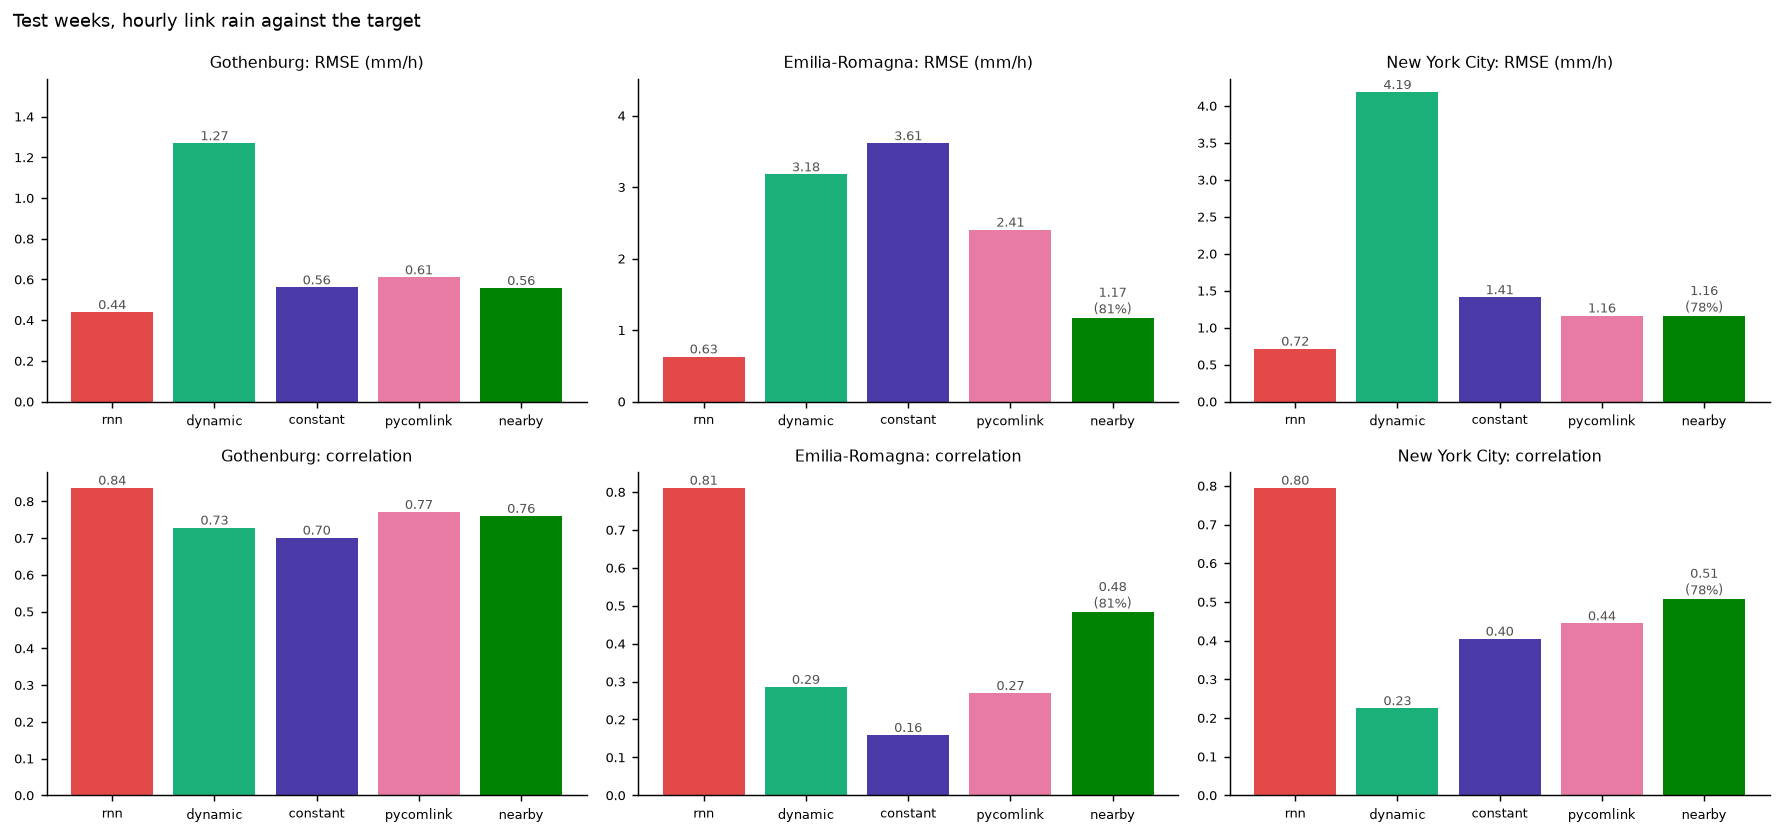

In [6]:
from cml_rnn import report
FIG = Path("../results") / MODEL / "figures"
report.scores_figure(table, FIG / "scores_target.png")
from IPython.display import Image
Image(FIG / "scores_target.png")

## What the difference looks like

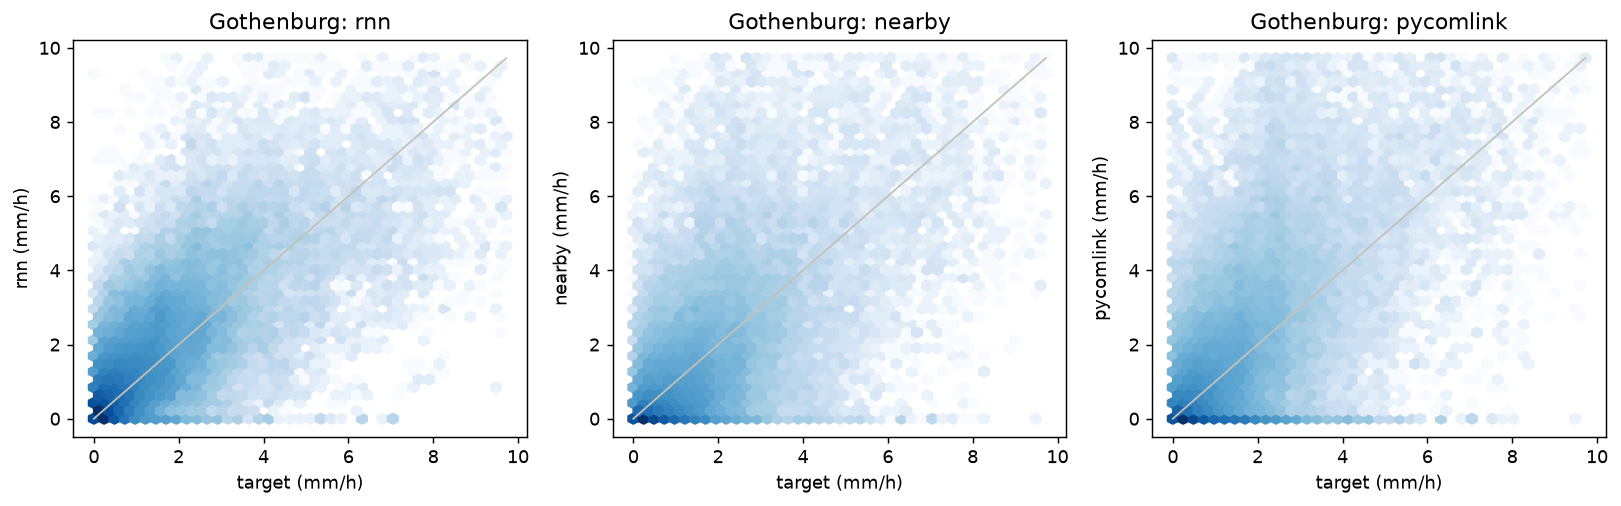

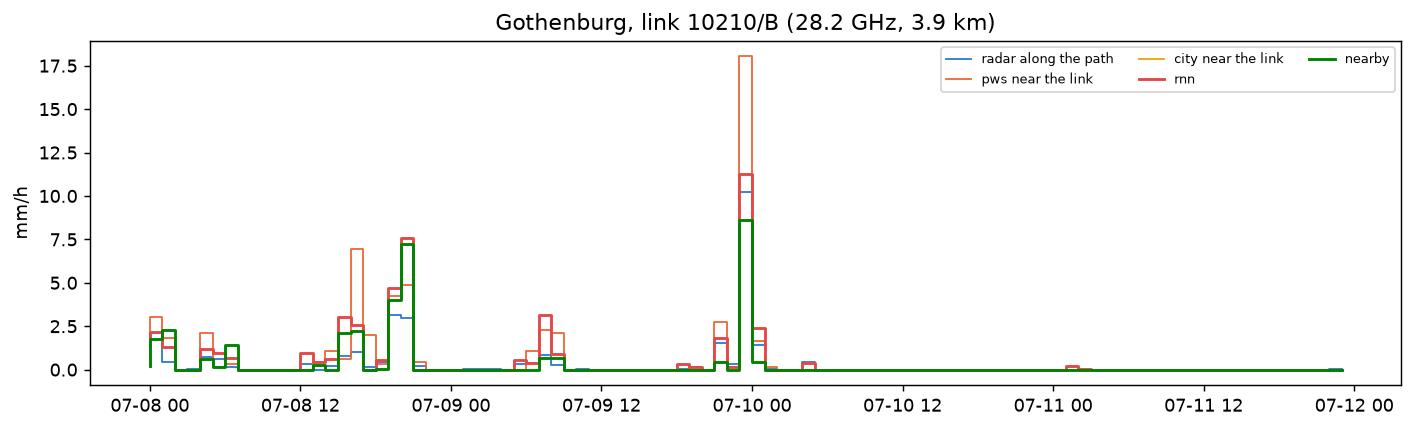

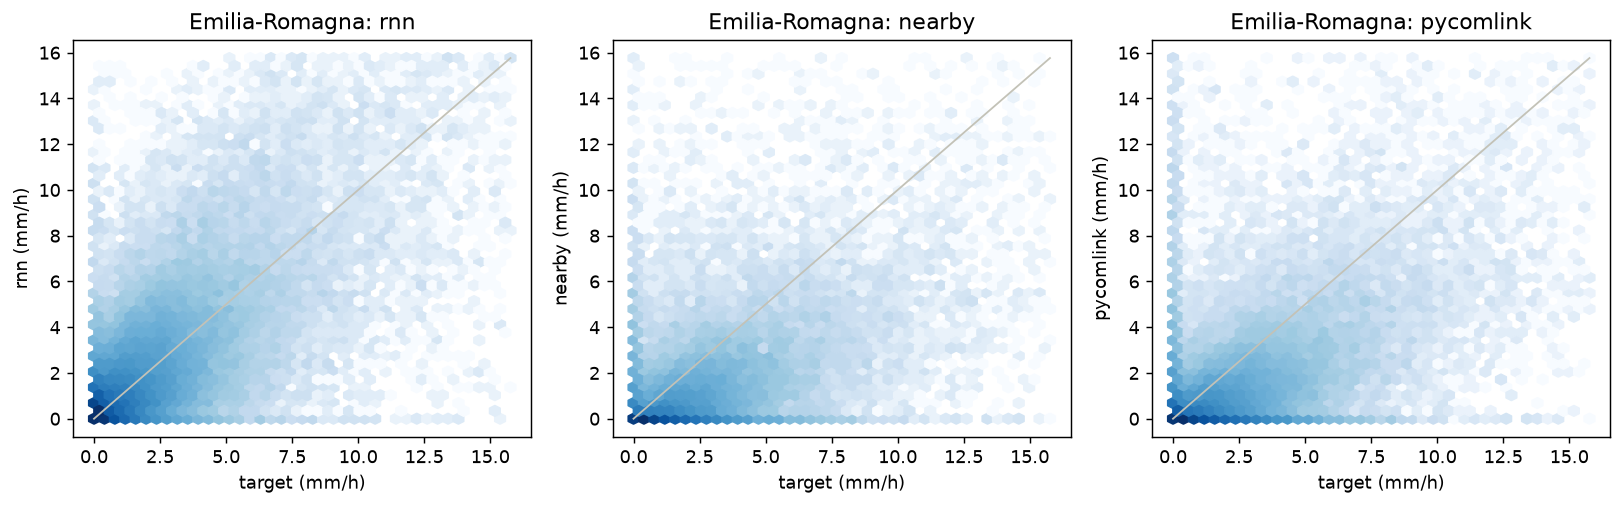

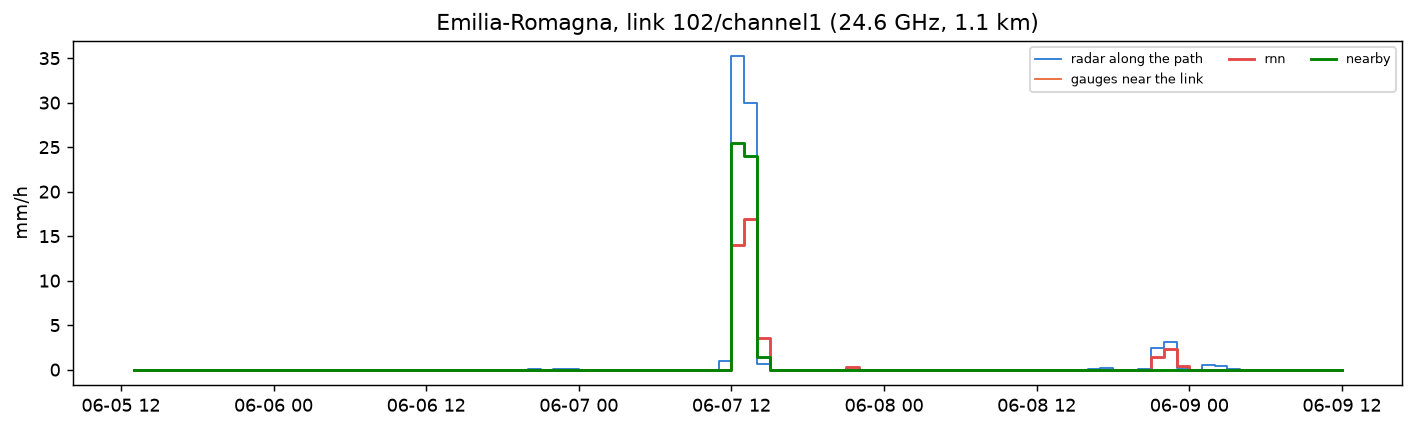

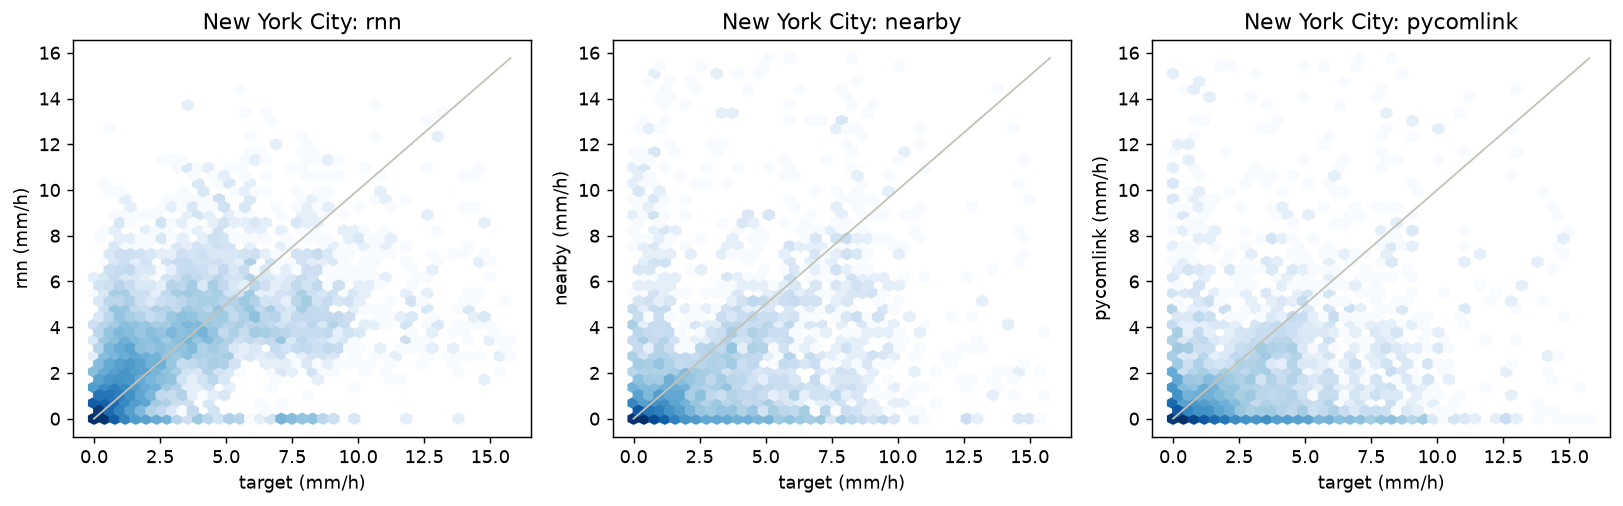

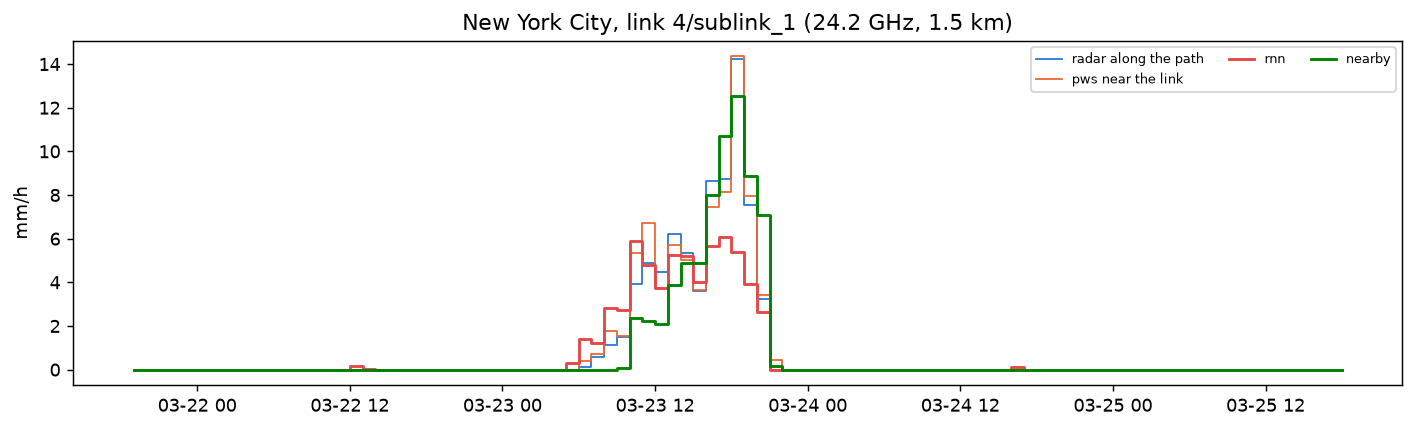

In [7]:
for n, (d, est) in ests.items():
    report.scatter_figure(d, est, FIG / f"scatter_{n}.png")
    report.series_figure(d, est, FIG / f"series_{n}.png")
from IPython.display import display
for n in ests:
    display(Image(FIG / f"scatter_{n}.png"))
    display(Image(FIG / f"series_{n}.png"))